<a href="https://colab.research.google.com/github/muhxz3/Food-Delivery-Data-Visualization/blob/main/Food_Delivery_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# loading the dataset
data = pd.read_csv("/content/Day14_Food_Delivery_Visualization_Dataset.csv")
data

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,FD0356,2025-05-17,May,Saturday,Hyderabad,South Indian,Website,Hot,173,345.70,54617.02,23218.25,3545.94,34.0,4.38,32.7
356,FD0357,2025-09-19,September,Friday,Jaipur,Chinese,App,Clear,84,368.12,43172.89,36244.79,7910.39,27.6,4.39,42.6
357,FD0358,2025-04-18,April,Friday,Bengaluru,Biryani,Partner Platform,Rainy,148,431.35,67272.24,18853.98,6147.45,41.1,4.09,30.2
358,FD0359,2025-11-21,November,Friday,Mumbai,Healthy,App,Clear,179,483.13,88272.94,38950.88,13430.03,30.5,4.64,49.0


In [34]:
data.shape

(360, 16)

In [35]:
data.dtypes

,0
Order_Batch_ID,object
Date,object
Month,object
Day,object
City,object
Cuisine,object
Order_Channel,object
Weather,object
Orders,int64
Average_Order_Value,float64


In [36]:
# converting datatype of the feature Date
data['Date'] = pd.to_datetime(data["Date"])

In [37]:
data.dtypes

,0
Order_Batch_ID,object
Date,datetime64[ns]
Month,object
Day,object
City,object
Cuisine,object
Order_Channel,object
Weather,object
Orders,int64
Average_Order_Value,float64


In [38]:
data.isna().sum()

,0
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0


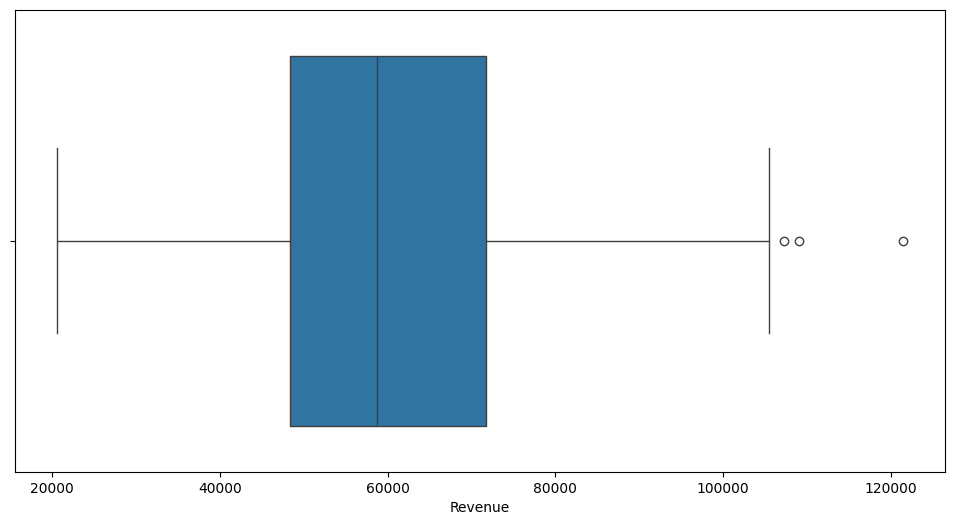

In [39]:
# identifying outliers

plt.figure(figsize=(12,6))
sns.boxplot(x=data["Revenue"])
plt.show()

In [40]:
q1 = data["Revenue"].quantile(0.25)
q3 = data["Revenue"].quantile(0.75)

IQRA = q3 - q1

lb = q1 - 1.5*IQRA
ub = q3 + 1.5*IQRA

data["Revenue"] = data["Revenue"].clip(lower=lb, upper=ub)

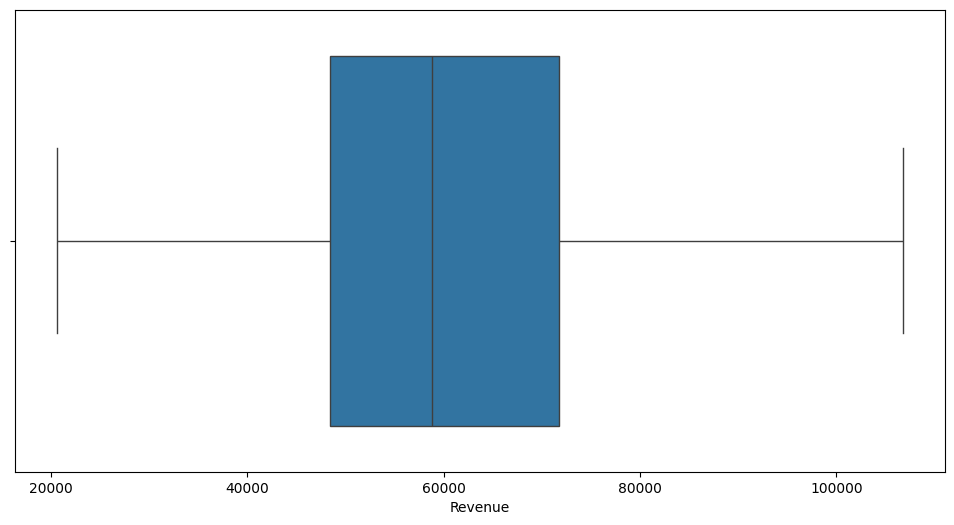

In [41]:
plt.figure(figsize=(12,6))
sns.boxplot(x=data["Revenue"])
plt.show()

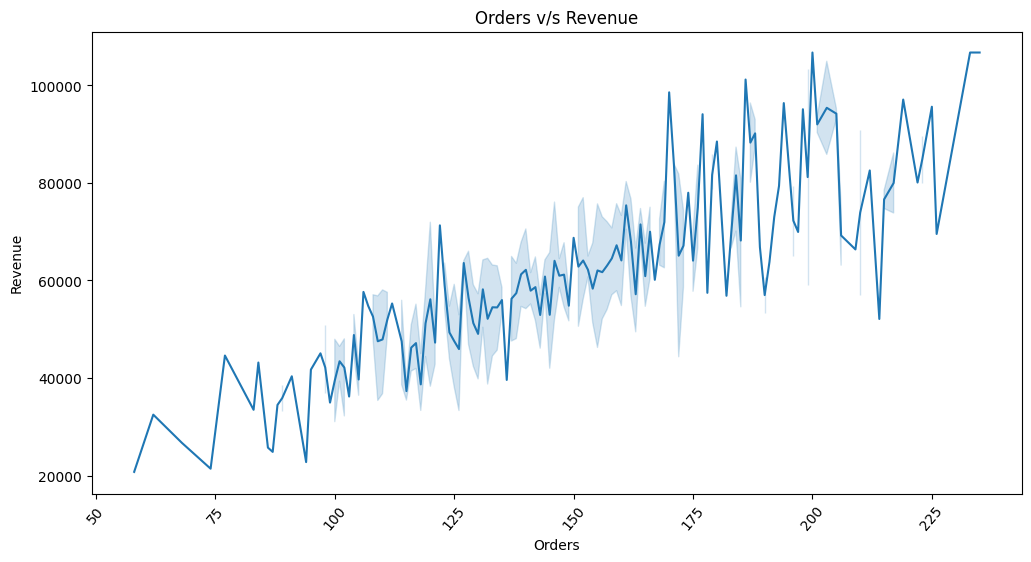

In [42]:
# line plot on Orders and Revenue

plt.figure(figsize=(12,6))
sns.lineplot(x=data["Orders"], y=data["Revenue"])

plt.title("Orders v/s Revenue")
plt.xlabel("Orders")
plt.ylabel("Revenue")
plt.xticks(rotation=50)
plt.show()

In [43]:
Max_Revenue = data[data["Revenue"] == data["Revenue"].max()][["Orders","Revenue"]]
Max_Revenue

,Orders,Revenue
185,235,106749.1075
273,233,106749.1075
349,200,106749.1075


##### KEY INSIGHT:
Highest Revenue was achieved when Orders were maximum

In [44]:
# city and its avg revenue on bar plot
avg_city_revenue = data.groupby("City")["Revenue"].mean().reset_index()
avg_city_revenue

,City,Revenue
0,Bengaluru,72359.999717
1,Chandigarh,50860.405500
2,Delhi,71852.526038
3,Hyderabad,58841.311250
4,Jaipur,50696.350000
5,Kochi,49461.841707
6,Mumbai,66582.153841
7,Pune,57292.229286


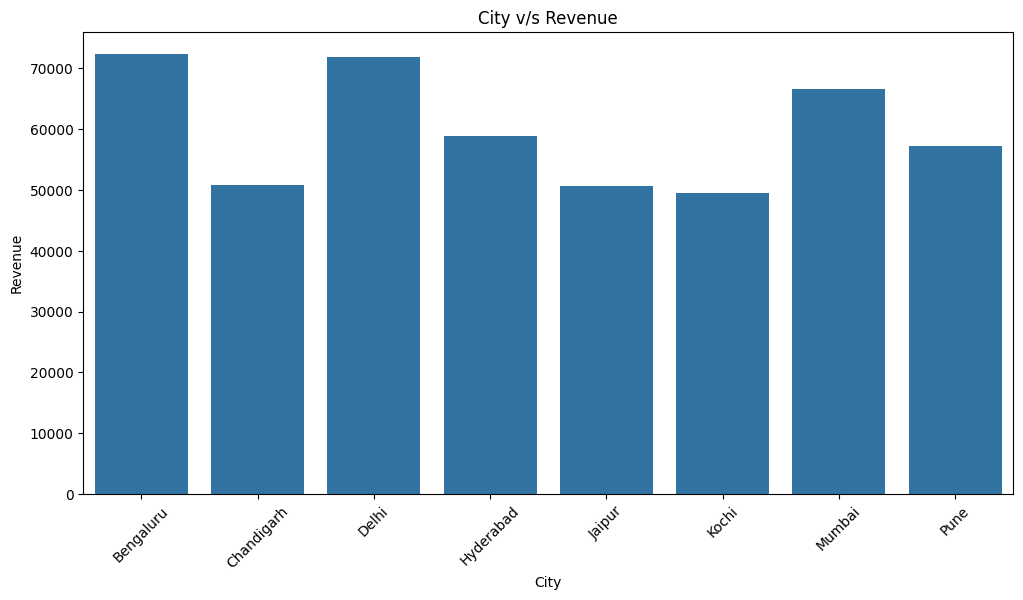

In [45]:
# bar plot on city v/s revenue

plt.figure(figsize=(12,6))
sns.barplot(x=avg_city_revenue["City"], y=avg_city_revenue["Revenue"])

plt.title("City v/s Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

##### KEY INSIGHT:
The city Bengaluru makes the highest revenue.

In [46]:
cuisine_orders = data.groupby("Cuisine")["Orders"].sum().reset_index()
cuisine_orders

,Cuisine,Orders
0,Biryani,8141
1,Chinese,9167
2,Fast Food,8602
3,Healthy,10024
4,North Indian,9030
5,South Indian,8189


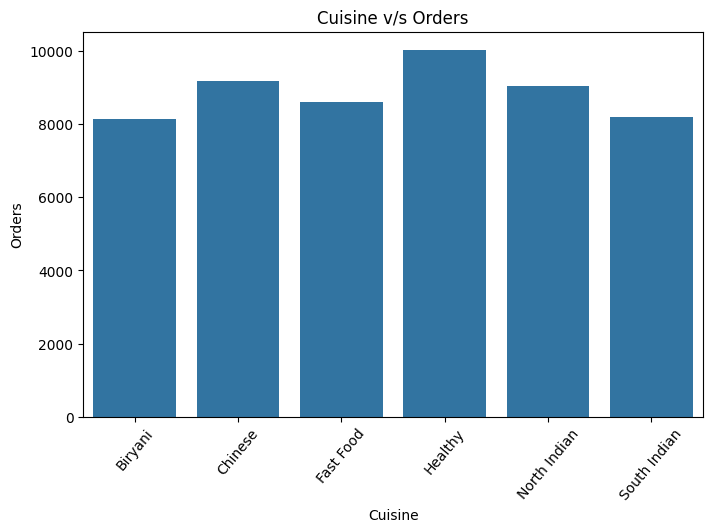

In [47]:
# bar plot on Cuisine v/s Orders

plt.figure(figsize=(8,5))
sns.barplot(x=cuisine_orders["Cuisine"],y=cuisine_orders["Orders"])

plt.title("Cuisine v/s Orders")
plt.xlabel("Cuisine")
plt.ylabel("Orders")
plt.xticks(rotation=50)
plt.show()


##### KEY INSIGHT:
Most orders are placed on Healthy Cuisine

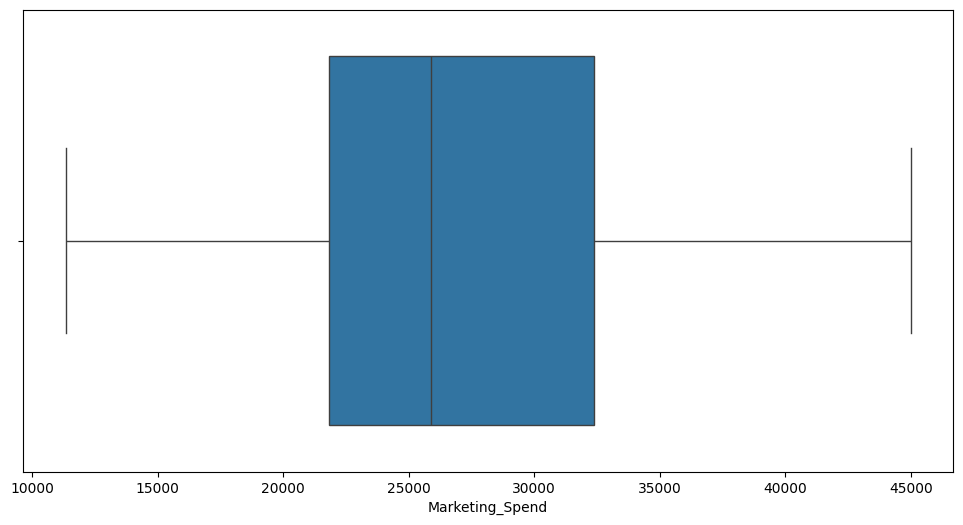

In [48]:
# identifying outliers

plt.figure(figsize=(12,6))
sns.boxplot(x=data["Marketing_Spend"])
plt.show()

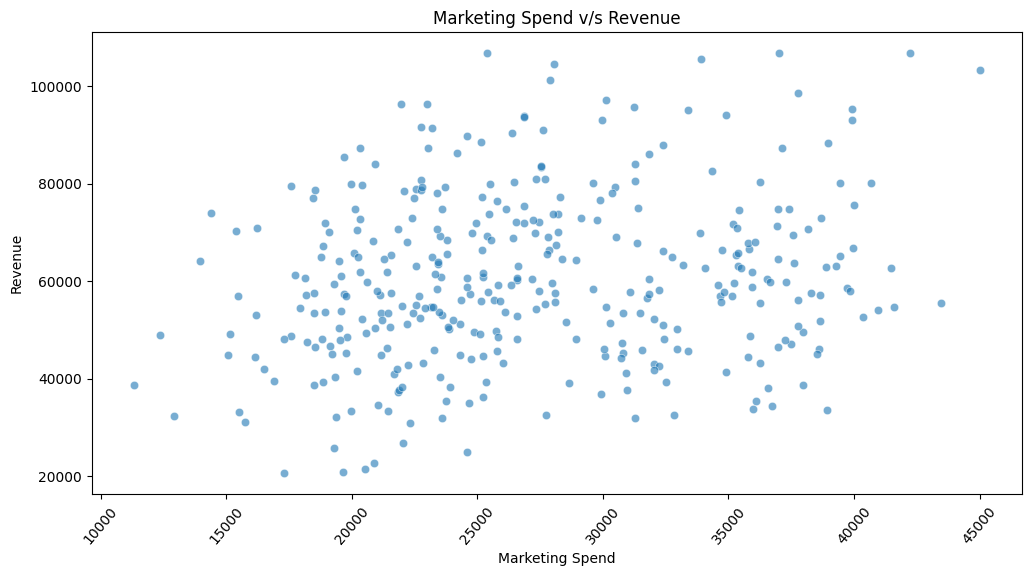

In [49]:
# relationship between marketing spend and revenue

plt.figure(figsize=(12,6))
sns.scatterplot(x=data["Marketing_Spend"], y=data["Revenue"],alpha=0.6)

plt.title("Marketing Spend v/s Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.xticks(rotation=50)
plt.show()

##### KEY INSIGHT:
There is a positive correlation between Marketing Spend and Revenue

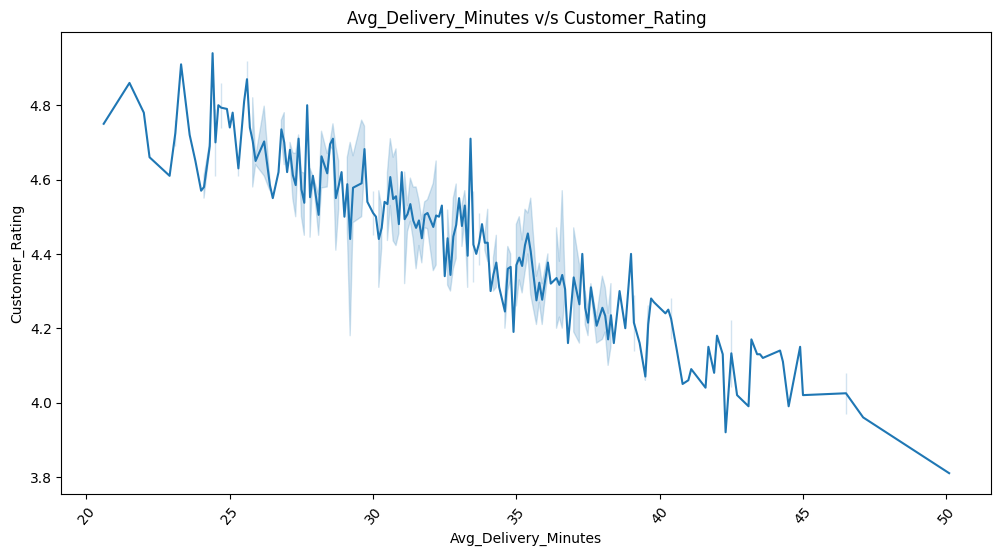

In [54]:
# line plot on Avg_Delivery_Minutes v/s Customr_Rating

plt.figure(figsize=(12,6))
sns.lineplot(x=data["Avg_Delivery_Minutes"], y=data["Customer_Rating"])

plt.title("Avg_Delivery_Minutes v/s Customer_Rating")
plt.xlabel("Avg_Delivery_Minutes")
plt.ylabel("Customer_Rating")
plt.xticks(rotation=50)
plt.show()

##### KEY INSIGHT:
When Avg_Delivery_Minutes increases, the Customer_Rating decreases.

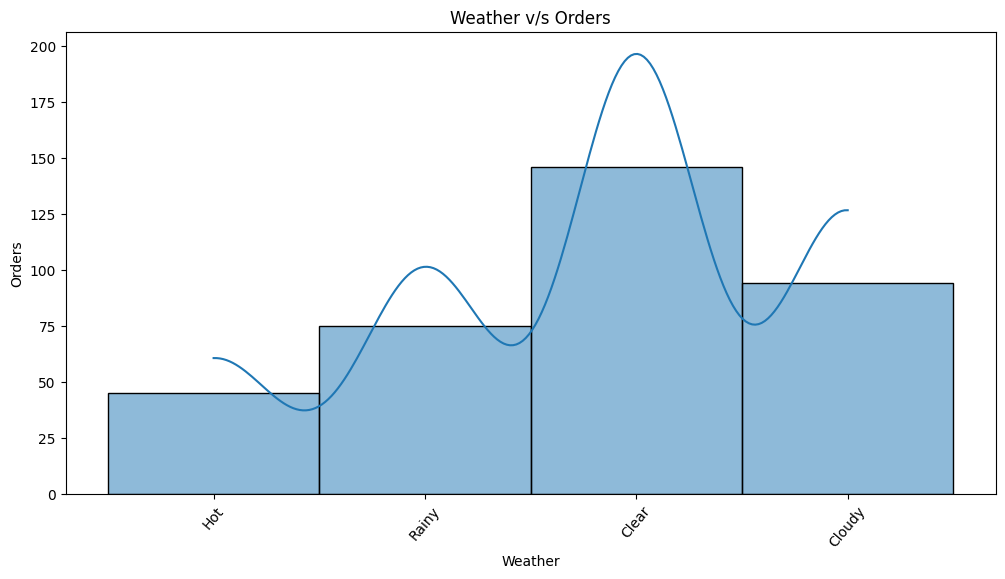

In [63]:
# histogram

plt.figure(figsize=(12,6))
sns.histplot(data=data,x="Weather",kde="True")

plt.title("Weather v/s Orders")
plt.xlabel("Weather")
plt.ylabel("Orders")
plt.xticks(rotation=50)
plt.show()

##### KEY INSIGHT:
Most orders are placed on Clear Weather and then on Cloudy days.

### SUMMARY
- The Weather affects the order and revenue very much.
- Delay deliveries increases bad customer ratings.
- There is no strong relation between marketing spend and revenue, yet it is positive.
- Most orders are placed on Healthy Cuisine.
- Bengaluru makes the highest revenue.

